In [1]:
import os
import re
import json
import glob

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import umap.umap_ as umap

import torch
from torch.utils.data import DataLoader
from sentence_transformers import SentenceTransformer, InputExample, losses

from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score, 
    classification_report, 
    silhouette_score, 
    davies_bouldin_score, 
    calinski_harabasz_score
)

/tmp/ipykernel_908/97990642.py:15: DeprecationWarning: Importing from 'sentence_transformers.losses' is deprecated and will be removed in a future version. Please use 'sentence_transformers.sentence_transformer.losses' instead.
  from sentence_transformers import SentenceTransformer, InputExample, losses


---

#### **01 ) - Upload de dados**

---

##### **1.1 ) - _Upload dos dados sintéticos_**

In [2]:
def consolidar_jsons_sinteticos(caminho_diretorio: str) -> dict:
    dataset_consolidado = {}
    
    padrao_busca = os.path.join(caminho_diretorio, "*.json")
    arquivos_json = glob.glob(padrao_busca)
    
    if not arquivos_json:
        print(f"| Falha de leitura: Nenhum arquivo .json encontrado no diretório '{caminho_diretorio}'.")
        return dataset_consolidado

    for caminho_arquivo in arquivos_json:
        nome_arquivo = os.path.basename(caminho_arquivo)
        
        try:
            with open(caminho_arquivo, "r", encoding="utf-8") as arquivo:
                conteudo = json.load(arquivo)
                
                if isinstance(conteudo, dict):
                    dataset_consolidado.update(conteudo)
                else:
                    print(f"| Falha estrutural: O arquivo '{nome_arquivo}' não possui um dicionário na raiz. Ignorado.")
                    
        except json.JSONDecodeError:
            print(f"| Falha de parse: O arquivo '{nome_arquivo}' está corrompido ou não é um JSON válido.")
        except Exception as e:
            print(f"| Falha de I/O no arquivo '{nome_arquivo}': {e}")
            
    return dataset_consolidado

---

##### **1.2 ) - _Upload dos dados reais_**

In [3]:
def carregar_dados_reais(caminho: str) -> pd.DataFrame:
    try:
        with open(caminho, 'r', encoding='utf-8') as f:
            dados_json = json.load(f)
        
        df_prosper = pd.DataFrame(dados_json)
        return df_prosper
        
    except FileNotFoundError:
        print(f"| Falha de I/O: O arquivo '{caminho}' não foi encontrado.")
        return pd.DataFrame()
    except json.JSONDecodeError as e:
        print(f"| Falha de parse estrutural: O arquivo JSON contém erros de formatação na sintaxe. {e}")
        return pd.DataFrame()
    except ValueError as e:
        print(f"| Falha de conversão: Os dados carregados não formam uma estrutura tabular válida para o Pandas. {e}")
        return pd.DataFrame()

---

#### **02 ) - Execução do modelo de embeddings**

In [4]:
def padronizar_lexico(dic_variaveis):
    textos_padronizados = []
    labels_categorias = []

    for macro_classe, lista_vars in dic_variaveis.items():
        for var in lista_vars:
            texto_limpo = var.lower()
            texto_limpo = re.sub(r'_', ' ', texto_limpo)
            textos_padronizados.append(texto_limpo)
            labels_categorias.append(macro_classe)

    return textos_padronizados, labels_categorias

In [5]:
def calibrar_modelo_dominio(textos, labels, nome_modelo_base, epochs=5, batch_size=16):
    print(f"\nIniciando Fine-Tuning de Alta Repulsão: {nome_modelo_base}")
    dispositivo = 'cuda' if torch.cuda.is_available() else 'cpu'
    modelo = SentenceTransformer(nome_modelo_base, device=dispositivo)

    encoder = LabelEncoder()
    labels_int = encoder.fit_transform(labels)

    train_examples = []
    for texto, label in zip(textos, labels_int):
        train_examples.append(InputExample(texts=[texto], label=label))

    train_dataloader = DataLoader(train_examples, shuffle=True, batch_size=batch_size)

    train_loss = losses.BatchHardTripletLoss(
        model=modelo,
        distance_metric=losses.BatchHardTripletLossDistanceFunction.cosine_distance,
        margin=0.6
    )

    modelo.fit(
        train_objectives=[(train_dataloader, train_loss)],
        epochs=epochs,
        warmup_steps=int(len(train_dataloader) * 0.1),
        show_progress_bar=True
    )

    return modelo

In [6]:
from sklearn.metrics.pairwise import cosine_similarity

def processar_e_plotar_modelos(dic_variaveis, lista_modelos):
    textos_limpos, labels = padronizar_lexico(dic_variaveis)
    n_modelos = len(lista_modelos)
    fig, axes = plt.subplots(1, n_modelos, figsize=(10 * n_modelos, 7))

    if n_modelos == 1:
        axes = [axes]

    modelo_final_calibrado = None

    for ax, nome_modelo in zip(axes, lista_modelos):
        modelo_calibrado = calibrar_modelo_dominio(textos_limpos, labels, nome_modelo)
        vetores = modelo_calibrado.encode(textos_limpos, show_progress_bar=False)

        try:
            sil_score = silhouette_score(vetores, labels)
            db_score = davies_bouldin_score(vetores, labels)
            ch_score = calinski_harabasz_score(vetores, labels)
            
            classes_unicas = np.unique(labels)
            sim_intraclasse_lista = []
            
            for c in classes_unicas:
                indices = [i for i, lbl in enumerate(labels) if lbl == c]
                if len(indices) > 1:
                    vetores_c = np.array(vetores)[indices]
                    sim_matrix = cosine_similarity(vetores_c)
                    pares_sim = sim_matrix[np.triu_indices_from(sim_matrix, k=1)]
                    if len(pares_sim) > 0:
                        sim_intraclasse_lista.append(np.mean(pares_sim))
            
            sim_intraclasse_media = np.mean(sim_intraclasse_lista) if sim_intraclasse_lista else 0.0
            
            titulo_metricas = (
                f"{nome_modelo}\n"
                f"Silhouette: {sil_score:.3f} | Davies-Bouldin: {db_score:.3f}\n"
                f"Calinski-Harabasz: {ch_score:.1f} | Cos. Intraclasse: {sim_intraclasse_media:.3f}"
            )
        except ValueError:
            titulo_metricas = f"{nome_modelo}\nFalha no cálculo de métricas estruturais"

        redutor = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
        vetores_2d = redutor.fit_transform(vetores)

        df_plot = pd.DataFrame({
            'Componente 1': vetores_2d[:, 0],
            'Componente 2': vetores_2d[:, 1],
            'Macro Classe': labels
        })

        sns.scatterplot(
            data=df_plot, x='Componente 1', y='Componente 2',
            hue='Macro Classe', palette='tab20', s=100, ax=ax, alpha=0.8
        )

        ax.set_title(titulo_metricas, pad=15)
        ax.legend(title='Macro Classes', bbox_to_anchor=(1.05, 1), loc='upper left')

        modelo_final_calibrado = modelo_calibrado

    plt.tight_layout()
    plt.show()

    return modelo_final_calibrado, textos_limpos, labels

---

#### **03 ) - Classificador**

---

##### **3.1 ) - _Treinamento do classificador_**

In [7]:
def treinar_classificador(modelo_embeddings, textos_treino, labels_treino, modelo_classificador):
    """Treina um classificador injetado como dependência."""
    print(f"| Extraindo embeddings para treino...")
    vetores_treino = modelo_embeddings.encode(textos_treino, show_progress_bar=False)

    encoder = LabelEncoder()
    y_treino = encoder.fit_transform(labels_treino)

    print(f"| Treinando o classificador {modelo_classificador.__class__.__name__}...")
    modelo_classificador.fit(vetores_treino, y_treino)

    return modelo_classificador, encoder

In [8]:
def predict_lote(textos, modelo_embeddings, classificador, encoder, limiar_confianca=0.50):
    vetores_entrada = modelo_embeddings.encode(textos.tolist(), show_progress_bar=False)
    probabilidades_todas = classificador.predict_proba(vetores_entrada)
    
    indices_vencedores = np.argmax(probabilidades_todas, axis=1)
    probabilidades_vencedoras = np.max(probabilidades_todas, axis=1)
    
    classes_finais = encoder.inverse_transform(indices_vencedores)
    
    resultados = []
    for prob, classe in zip(probabilidades_vencedoras, classes_finais):
        if prob < limiar_confianca:
            resultados.append({
                "classe_predita": "UNCLASSIFIED",
                "confianca": float(prob),
                "alerta": f"Rejeitado (Limiar: {limiar_confianca})"
            })
        else:
            resultados.append({
                "classe_predita": classe,
                "confianca": float(prob),
                "alerta": None
            })
            
    return pd.DataFrame(resultados)

---

##### **3.2 ) - _Gerar uma predição_**

In [9]:
def predict_individual(texto, modelo_embeddings, classificador, encoder, limiar_confianca=0.50):
    """Realiza a inferência para uma única string isolada."""
    
    vetor_entrada = modelo_embeddings.encode([texto], show_progress_bar=False)
    
    probabilidades = classificador.predict_proba(vetor_entrada)[0]
    
    indice_vencedor = np.argmax(probabilidades)
    probabilidade_vencedora = probabilidades[indice_vencedor]
    
    if probabilidade_vencedora < limiar_confianca:
        return {
            "classe_predita": "UNCLASSIFIED",
            "confianca": float(probabilidade_vencedora),
            "alerta": f"Rejeitado pela trava de segurança (Limiar: {limiar_confianca})"
        }
        
    classe_final = encoder.inverse_transform([indice_vencedor])[0]
    
    return {
        "classe_predita": classe_final,
        "confianca": float(probabilidade_vencedora),
        "alerta": None
    }

In [10]:
def avaliar_modelos(dicionario_modelos, modelo_embeddings, textos_base, labels_base, df_consolidado, limiar_confianca=0.50):
    """Itera sobre múltiplos modelos, treina, prediz e consolida métricas."""
    relatorios = {}
    
    y_real = df_consolidado['macro_class']
    textos_teste = df_consolidado['desc']
    
    for nome, classificador_base in dicionario_modelos.items():
        print(f"\n================ Iniciando avaliação: {nome} ================")
        
        modelo_treinado, encoder = treinar_classificador(
            modelo_embeddings, textos_base, labels_base, classificador_base
        )
        
        print("| Realizando predições no conjunto de teste...")
        df_resultados = predict_lote(
            textos_teste, modelo_embeddings, modelo_treinado, encoder, limiar_confianca
        )
        
        y_pred = df_resultados['classe_predita']
        
        acuracia = accuracy_score(y_real, y_pred)
        relatorio = classification_report(y_real, y_pred, zero_division=0)
        
        print(f"| Acurácia Global ({nome}): {acuracia:.4f}")
        
        relatorios[nome] = {
            "acuracia": acuracia,
            "relatorio": relatorio,
            "modelo": modelo_treinado,
            "encoder": encoder
        }
        
    return relatorios

---

#### **04 ) - Execução**


Iniciando Fine-Tuning de Alta Repulsão: BAAI/bge-large-en-v1.5


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

Step,Training Loss


/home/andre/miniconda3/envs/sematic/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


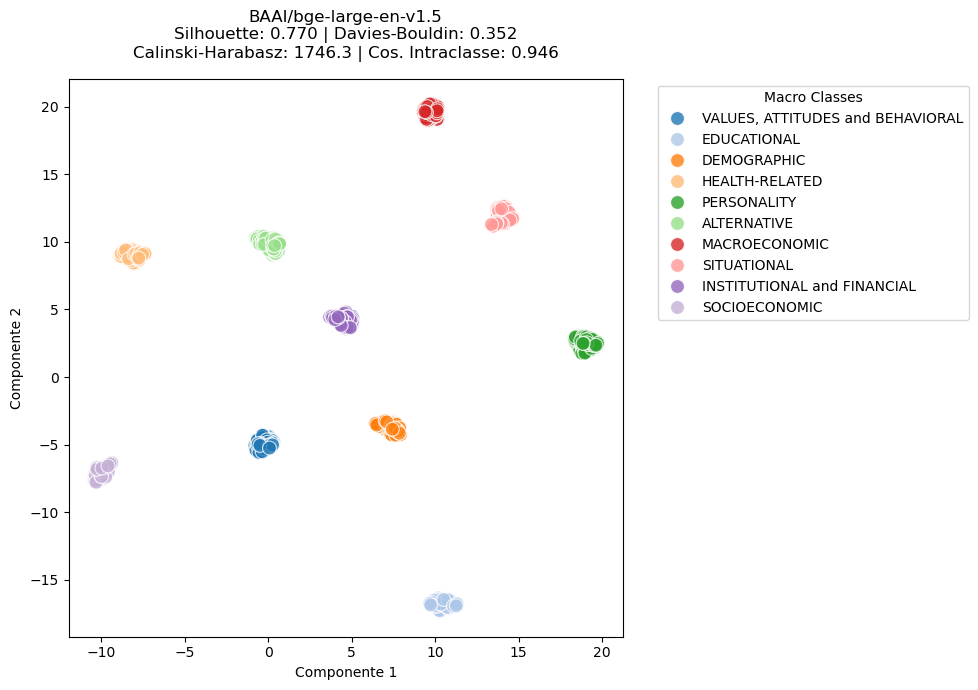

In [11]:
modelos_alvo = ['BAAI/bge-large-en-v1.5']
dados = consolidar_jsons_sinteticos("../data/output/SynteticData")
modelo_embeddings, textos_base, labels_base = processar_e_plotar_modelos(dados, modelos_alvo)

---

#### **05 ) - Avaliação com dados reais**

---

##### **5.1 ) - _Criando dataset de teste_**

In [12]:
df_ProsperLoanData = carregar_dados_reais("../data/input/PL.json")

df_real_classificado_completo = pd.read_csv("../data/input/MacroTaxonomyClassification.csv")
df_real_classificado = df_real_classificado_completo[df_real_classificado_completo['id'] == 'd15'].copy()

df_consolidado = pd.merge(df_ProsperLoanData, df_real_classificado, left_on='var', right_on='Col', how='inner')

df_consolidado = df_consolidado.rename(columns={'Col_Standardized': 'macro_class'})
df_consolidado = df_consolidado[['id', 'var', 'desc', 'macro_class']]
df_consolidado = df_consolidado.reset_index(drop=True)

df_consolidado.head()

,id,var,desc,macro_class
0,d15,ListingKey,"Unique key for each listing, same value as the...",UNCLASSIFIED
1,d15,ListingNumber,The number that uniquely identifies the listin...,UNCLASSIFIED
2,d15,ListingCreationDate,The date the listing was created.,UNCLASSIFIED
3,d15,CreditGrade,The Credit rating that was assigned at the tim...,INSTITUTIONAL and FINANCIAL
4,d15,Term,The length of the loan expressed in months.,INSTITUTIONAL and FINANCIAL


---

##### **5.1 ) - _Executando a avaliação_**

In [13]:
modelos_para_testar = {
    "Regressao_Logistica": LogisticRegression(max_iter=1000, random_state=42),
    "Random_Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM_Linear": SVC(kernel='linear', probability=True, random_state=42)
}

resultados_finais = avaliar_modelos(
    dicionario_modelos=modelos_para_testar,
    modelo_embeddings=modelo_embeddings,
    textos_base=textos_base,
    labels_base=labels_base,
    df_consolidado=df_consolidado,
    limiar_confianca=0.50
)

print("\n================ RESUMO FINAL ================")
for nome, metricas in resultados_finais.items():
    print(f"\nModelo: {nome}")
    print(f"Acurácia: {metricas['acuracia']:.4f}")
    print(metricas['relatorio'])


================ Iniciando avaliação: Regressao_Logistica ================
| Extraindo embeddings para treino...
| Treinando o classificador LogisticRegression...
| Realizando predições no conjunto de teste...
| Acurácia Global (Regressao_Logistica): 0.7342

================ Iniciando avaliação: Random_Forest ================
| Extraindo embeddings para treino...
| Treinando o classificador RandomForestClassifier...
| Realizando predições no conjunto de teste...
| Acurácia Global (Random_Forest): 0.7342

================ Iniciando avaliação: SVM_Linear ================
| Extraindo embeddings para treino...
| Treinando o classificador SVC...
| Realizando predições no conjunto de teste...
| Acurácia Global (SVM_Linear): 0.7468

================ RESUMO FINAL ================

Modelo: Regressao_Logistica
Acurácia: 0.7342
                             precision    recall  f1-score   support

                ALTERNATIVE       0.00      0.00      0.00         5
                DEMOGRAPHIC    

---

#### **06 ) - Gerador de predições unitárias**

In [14]:
input_teste = """Bachelors, Some-college, 11th, HS-grad, Prof-school, Assoc-acdm, Assoc-voc, 9th, 7th-8th, 12th, Masters, 1st-4th, 10th, Doctorate, 5th-6th, Preschool."""

In [15]:
modelo_escolhido = resultados_finais['Regressao_Logistica']['modelo']
encoder_escolhido = resultados_finais['Regressao_Logistica']['encoder']

resultado_unico = predict_individual(
    texto=input_teste,
    modelo_embeddings=modelo_embeddings,
    classificador=modelo_escolhido,
    encoder=encoder_escolhido,
    limiar_confianca=0.50
)

print(f"\n| Input: '{input_teste}'")
print(f"| Predição: {resultado_unico['classe_predita']} - Confiança: {resultado_unico['confianca']:.2f}")
if resultado_unico['alerta']:
    print(f"| Alerta: {resultado_unico['alerta']}")


| Input: 'Bachelors, Some-college, 11th, HS-grad, Prof-school, Assoc-acdm, Assoc-voc, 9th, 7th-8th, 12th, Masters, 1st-4th, 10th, Doctorate, 5th-6th, Preschool.'
| Predição: EDUCATIONAL - Confiança: 0.57
